In [3]:
from stress_risk.behavior.utils import get_data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os.path as op
import bambi
bids_folder = '/Users/mrenke/data/ds-stressrisk'

target_folder = op.join(bids_folder, 'derivatives', 'cogmodels')
df = get_data()
df['x'] = df['log(risky/safe)']


# env: behav_fit2 - works
# plot raw behavior in plot_rawData.ipynb


/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# start probit modelling

n_model = 1

if n_model == 1:
    formulae = 'chose_risky ~ x*session*group + (x*session|subject)' # 1
elif n_model == 2:
    formulae = 'chose_risky ~ x*session:group + (x*session|subject)' # no main effect of group # 2
elif n_model == 3:
    formulae = 'chose_risky ~ x*session + session:group + x*session:group + (x*session|subject)' # 3

model = bambi.Model(formulae, link='probit', family='bernoulli', data=df.reset_index())

model

Formula: chose_risky ~ x*session*group + (x*session|subject)
Family name: Bernoulli
Link: probit
Observations: 11891
Priors:
  Common-level effects
    Intercept ~ Normal(mu: 0, sigma: 11.2709)
    x ~ Normal(mu: 0, sigma: 7.45)
    session ~ Normal(mu: 0, sigma: 5.0)
    x:session ~ Normal(mu: 0, sigma: 3.9136)
    group ~ Normal(mu: 0, sigma: 5.0)
    x:group ~ Normal(mu: 0, sigma: 5.8075)
    session:group ~ Normal(mu: 0, sigma: 3.0135)
    x:session:group ~ Normal(mu: 0, sigma: 3.5542)

  Group-level effects
    1|subject ~ Normal(mu: 0, sigma: HalfNormal(sigma: 11.2709))
    x|subject ~ Normal(mu: 0, sigma: HalfNormal(sigma: 7.45))
    session|subject ~ Normal(mu: 0, sigma: HalfNormal(sigma: 5.0))
    x:session|subject ~ Normal(mu: 0, sigma: HalfNormal(sigma: 3.9136))

In [5]:
model

Formula: chose_risky ~ x*session*group + (x*session|subject)
Family name: Bernoulli
Link: probit
Observations: 11891
Priors:
  Common-level effects
    Intercept ~ Normal(mu: 0, sigma: 11.2709)
    x ~ Normal(mu: 0, sigma: 7.45)
    session ~ Normal(mu: 0, sigma: 5.0)
    x:session ~ Normal(mu: 0, sigma: 3.9136)
    group ~ Normal(mu: 0, sigma: 5.0)
    x:group ~ Normal(mu: 0, sigma: 5.8075)
    session:group ~ Normal(mu: 0, sigma: 3.0135)
    x:session:group ~ Normal(mu: 0, sigma: 3.5542)

  Group-level effects
    1|subject ~ Normal(mu: 0, sigma: HalfNormal(sigma: 11.2709))
    x|subject ~ Normal(mu: 0, sigma: HalfNormal(sigma: 7.45))
    session|subject ~ Normal(mu: 0, sigma: HalfNormal(sigma: 5.0))
    x:session|subject ~ Normal(mu: 0, sigma: HalfNormal(sigma: 3.9136))

In [ ]:
# fit
traces = model.fit(init='adapt_diag', target_accept=0.9, draws=1000, tune=1000)

# save model fit
import arviz as az
az.to_netcdf(traces, op.join(target_folder, f'bambi-RNP-fit_trace_model{n_model}.netcdf'))


Modeling the probability that chose_risky==1
Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, x, session, x:session, group, x:group, session:group, x:session:group, 1|subject_sigma, 1|subject_offset, x|subject_sigma, x|subject_offset, session|subject_sigma, session|subject_offset, x:session|subject_sigma, x:session|subject_offset]
Process worker_chain_0:
Traceback (most recent call last):
  File "/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/pymc/parallel_sampling.py", line 126, in run
    self._start_loop()
  File "/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/pymc/parallel_sampling.py", line 166, in _start_loop
    msg = self._recv_msg()
  File "/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/pymc/parallel_sampling.py", line 157, in _recv_msg
    return self._msg_pipe.recv()
  File "/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.

KeyboardInterrupt: 

In [6]:
# function for geting parameters from trace with sesssion as factor
import scipy.stats as ss
def invprobit(x):
    return ss.norm.ppf(x)

def extract_rnp_precision(trace, model, data, group=False):

    data = data.reset_index()

    if group:
        fake_data = pd.MultiIndex.from_product([data.reset_index()['subject'].unique()[[0]],
                                                [0, 1],
                                                data['session'].unique(),
                                                data['group'].unique()],
                                                names=['subject', 'x', 'session', 'group']
                                                ).to_frame().reset_index(drop=True)
    else:
        fake_data = pd.MultiIndex.from_product([data.reset_index()['subject'].unique(),
                                                [0, 1],
                                                data['session'].unique(),
                                                data['group'].unique()],
                                                names=['subject', 'x', 'session', 'group']
                                                ).to_frame().reset_index(drop=True)

    #pred = model.predict(trace, 'mean', fake_data, inplace=False)['posterior']['chose_risky_mean']
    pred = model.predict(trace, 'mean', fake_data, inplace=False, include_group_specific=not group)['posterior']['chose_risky_mean']

    pred = pred.to_dataframe().unstack([0, 1])
    pred = pred.set_index(pd.MultiIndex.from_frame(fake_data))

    # return pred

    pred0 = pred.xs(0, 0, 'x')
    intercept = pd.DataFrame(invprobit(pred0), index=pred0.index, columns=pred0.columns)
    gamma = invprobit(pred.xs(1, 0, 'x')) - intercept

    return intercept, gamma

In [7]:
# get parameters from trace
import arviz as az

n_model = 3
if n_model == 1:
    formulae = 'chose_risky ~ x*session*group + (x*session|subject)' # 1
elif n_model == 2:
    formulae = 'chose_risky ~ x*session:group + (x*session|subject)' # no main effect of group # 2
elif n_model == 3:
    formulae = 'chose_risky ~ x*session + x*session:group + (x*session|subject)' # 3

model = bambi.Model(formulae, link='probit', family='bernoulli', data=df.reset_index())

traces= az.from_netcdf(op.join(target_folder, f'bambi-RNP-fit_trace_model{n_model}.netcdf'))
intercept, gamma = extract_rnp_precision(traces, model, df, False)
rnp = np.clip(np.exp(intercept/gamma), 0, 1)


/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


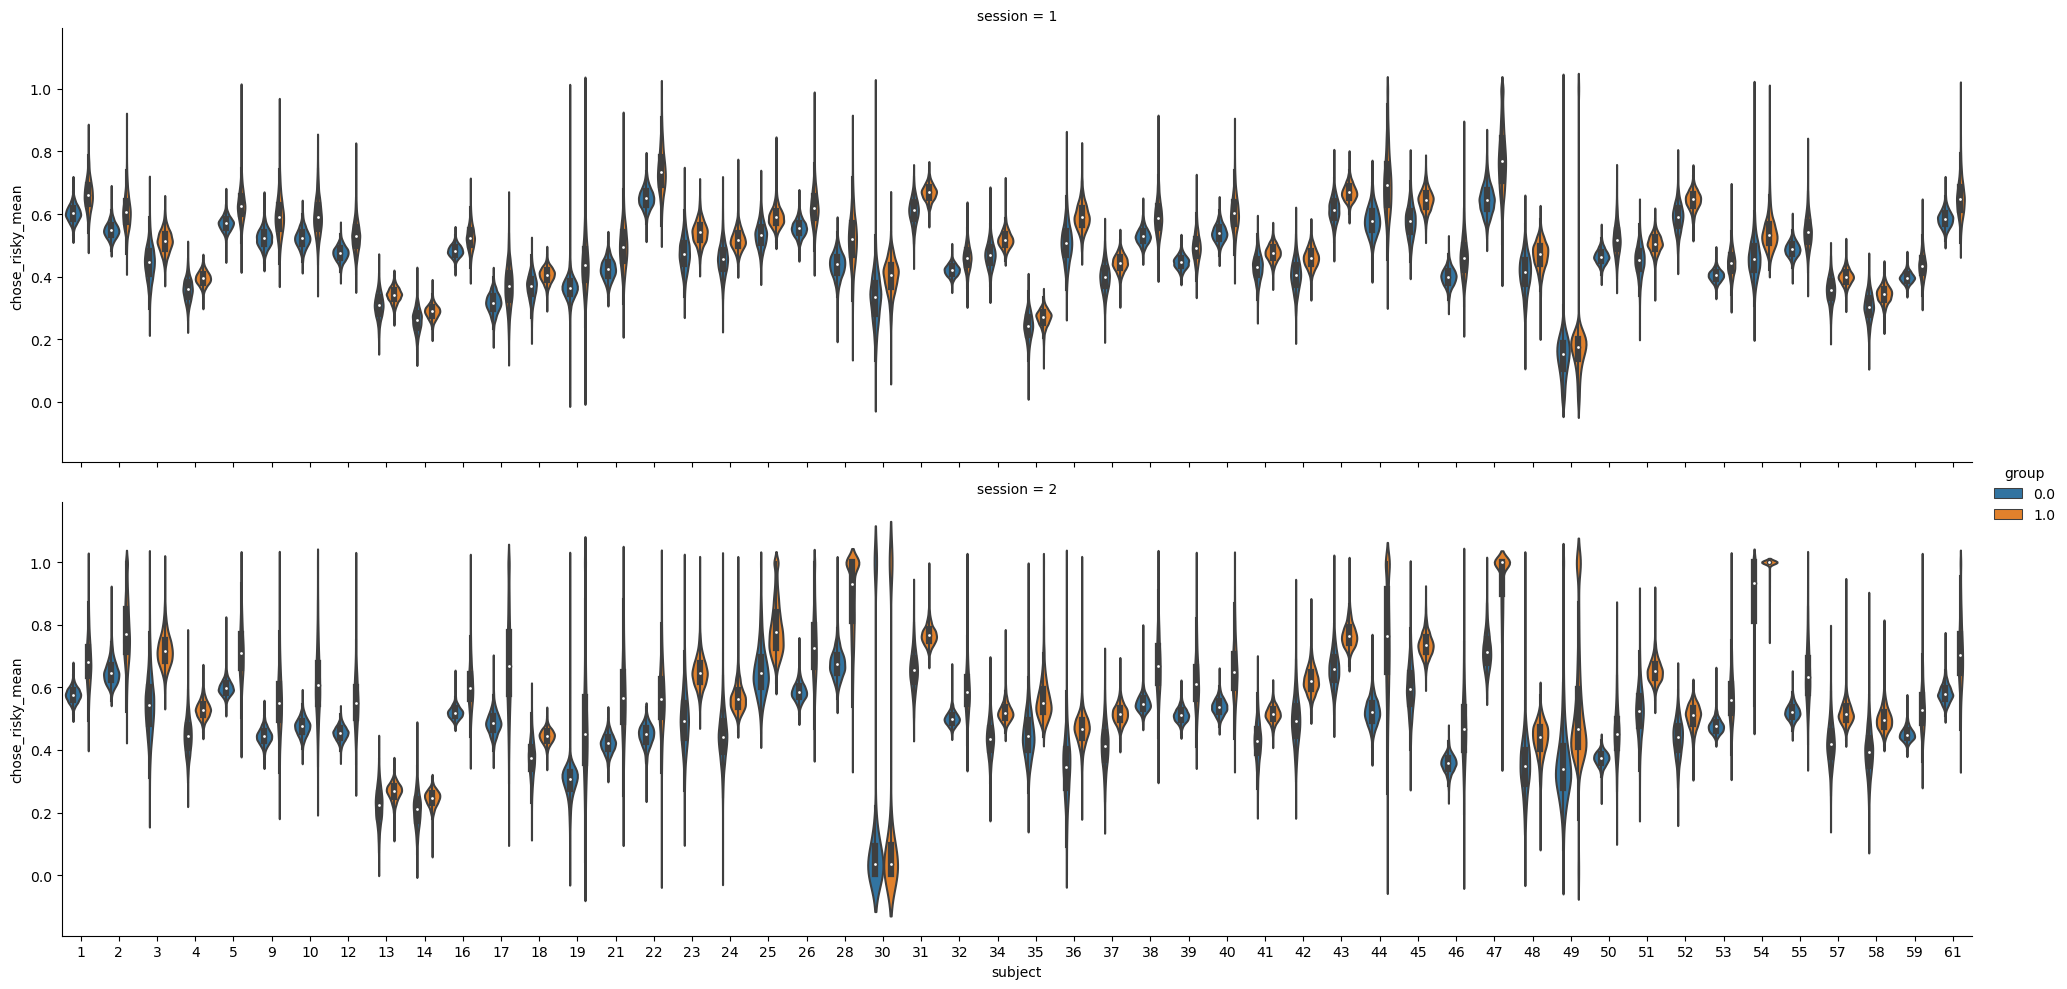

In [15]:
tmp = rnp.stack([-2, -1])

sns.catplot(tmp.reset_index(), x='subject', y='chose_risky_mean', row='session', hue='group', kind='violin', aspect=4.)

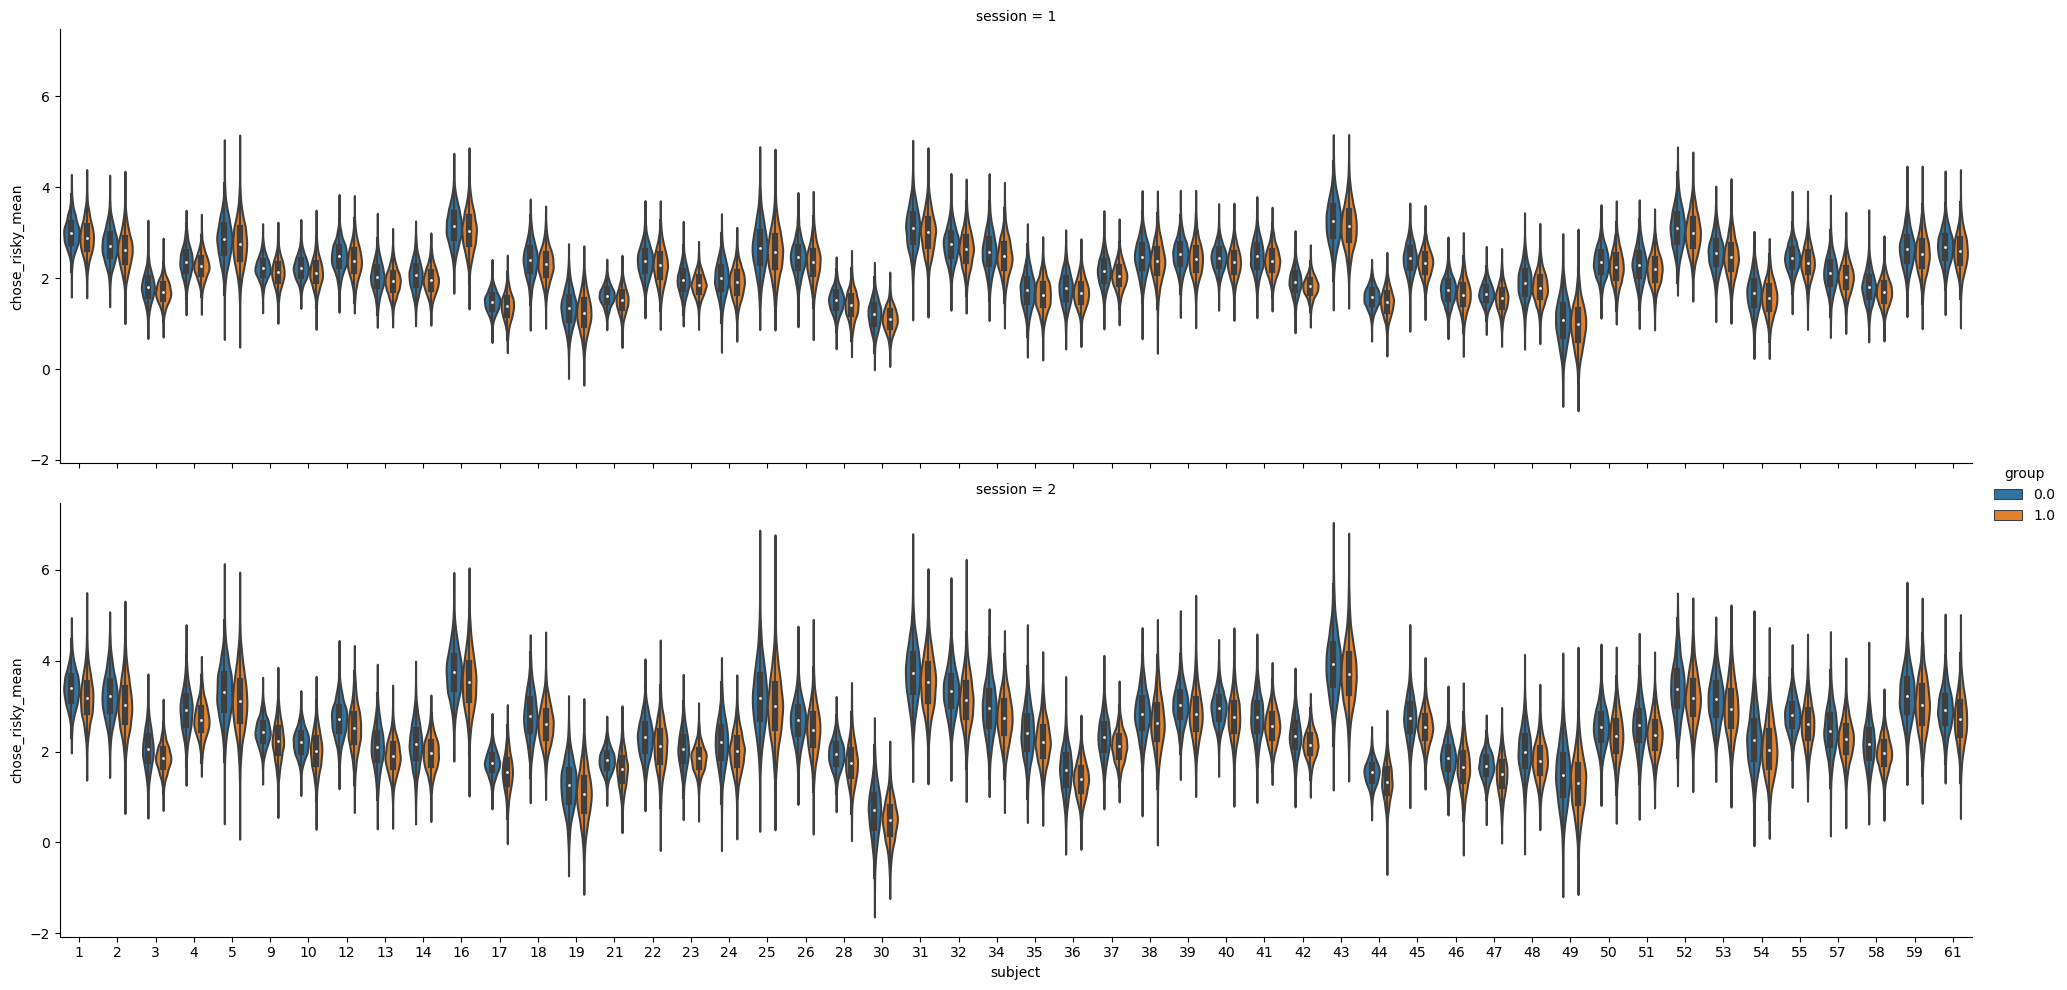

In [13]:
tmp = gamma.stack([-2, -1])

sns.catplot(tmp.reset_index(), x='subject', y='chose_risky_mean', row='session', hue='group', kind='violin', aspect=4.)

In [19]:
df

session        rt    n1    n2  prob1  prob2  choice  \
subject run trial_nr                                                        
1       1   1               1  0.476974  13.0  10.0   0.55    1.0    True   
            2               1  0.505059   8.0   7.0   0.55    1.0    True   
            3               1  0.609260  13.0   7.0   0.55    1.0   False   
            4               1  0.522144  38.0  28.0   0.55    1.0    True   
            5               1  0.608297  16.0  10.0   0.55    1.0   False   
...                       ...       ...   ...   ...    ...    ...     ...   
61      6   116             2  1.189453  39.0  14.0   0.55    1.0   False   
            117             2  0.755411  43.0  20.0   0.55    1.0   False   
            118             2  0.905503  34.0  14.0   0.55    1.0    True   
            119             2  1.873285  34.0  20.0   0.55    1.0    True   
            120             2  0.989251  42.0  28.0   0.55    1.0    True   

                      risky_first  chose_risky  n_risky  n_safe      frac  \
subject run trial_nr                                                        
1       1   1                True        False     13.0    10.0  1.300000   
            2                True        False      8.0     7.0  1.142857   
            3                True         True     13.0     7.0  1.857143   
            4                True        False     38.0    28.0  1.357143   
            5                True         True     16.0    10.0  1.600000   
...                           ...          ...      ...     ...       ...   
61      6   116              True         True     39.0    14.0  2.785714   
            117              True         True     43.0    20.0  2.150000   
            118              True        False     34.0    14.0  2.428571   
            119              True        False     34.0    20.0  1.700000   
            120              True        False     42.0    28.0  1.500000   

                      log(risky/safe)   log(n1) bin(risky/safe)    p1   p2  \
subject run trial_nr                                                         
1       1   1                0.262364  2.564949             32%  0.55  1.0   
            2                0.133531  2.079442             20%  0.55  1.0   
            3                0.619039  2.564949             56%  0.55  1.0   
            4                0.305382  3.637586             32%  0.55  1.0   
            5                0.470004  2.772589             44%  0.55  1.0   
...                               ...       ...             ...   ...  ...   
61      6   116              1.024504  3.663562             80%  0.55  1.0   
            117              0.765468  3.761200             56%  0.55  1.0   
            118              0.887303  3.526361             68%  0.55  1.0   
            119              0.530628  3.526361             32%  0.55  1.0   
            120              0.405465  3.737670             20%  0.55  1.0   

                      group         x  
subject run trial_nr                   
1       1   1           0.0  0.262364  
            2           0.0  0.133531  
            3           0.0  0.619039  
            4           0.0  0.305382  
            5           0.0  0.470004  
...                     ...       ...  
61      6   116         0.0  1.024504  
            117         0.0  0.765468  
            118         0.0  0.887303  
            119         0.0  0.530628  
            120         0.0  0.405465  

[11891 rows x 19 columns]

In [14]:
model1 = 

Formula: chose_risky ~ x*session + x*session:group + (x*session|subject)
Family name: Bernoulli
Link: probit
Observations: 11891
Priors:
  Common-level effects
    Intercept ~ Normal(mu: 0, sigma: 10.7979)
    x ~ Normal(mu: 0, sigma: 7.45)
    session ~ Normal(mu: 0, sigma: 5.0)
    x:session ~ Normal(mu: 0, sigma: 3.9136)
    session:group ~ Normal(mu: 0, sigma: 3.0135)
    x:session:group ~ Normal(mu: 0, sigma: 3.5542)

  Group-level effects
    1|subject ~ Normal(mu: 0, sigma: HalfNormal(sigma: 10.7979))
    x|subject ~ Normal(mu: 0, sigma: HalfNormal(sigma: 7.45))
    session|subject ~ Normal(mu: 0, sigma: HalfNormal(sigma: 5.0))
    x:session|subject ~ Normal(mu: 0, sigma: HalfNormal(sigma: 3.9136))

0.26525


<AxesSubplot: ylabel='Density'>

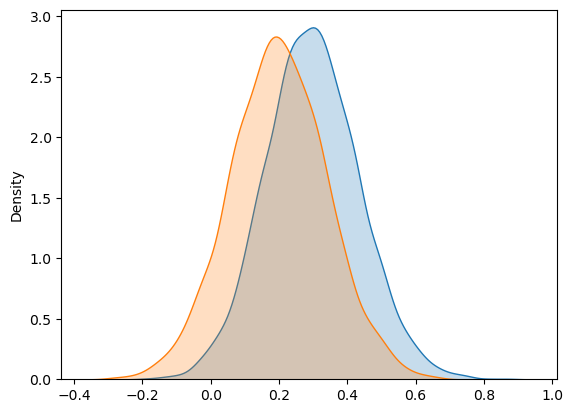

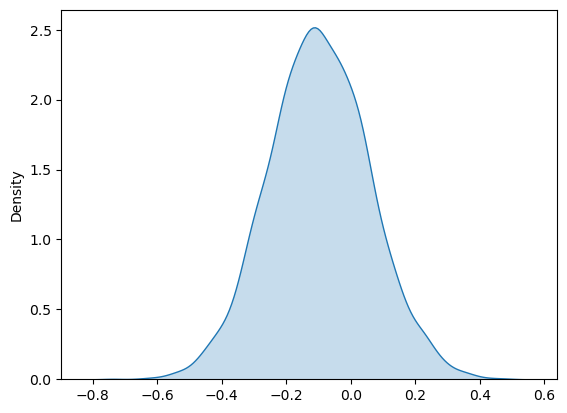

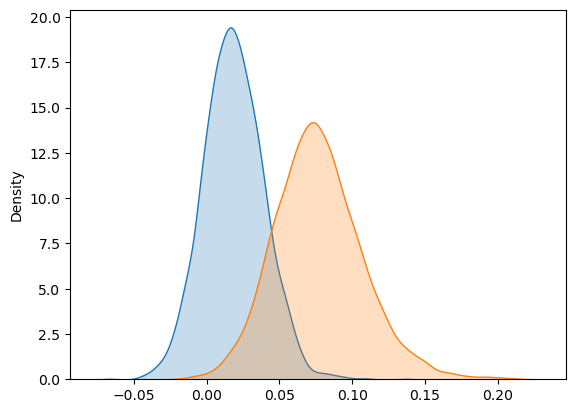

In [25]:
# intercept, gamma = extract_rnp_precision(traces, model, df, True)
# rnp = np.clip(np.exp(intercept/gamma), 0, 1)


# sns.kdeplot((gamma.loc[(1, 2, 0.0)] - gamma.loc[(1, 1, 0.0)]), fill=True)
# sns.kdeplot((gamma.loc[(1, 2, 1.0)] - gamma.loc[(1, 1, 1.0)]), fill=True)

# plt.figure()
# sns.kdeplot((gamma.loc[(1, 2, 1.0)] - gamma.loc[(1, 1, 1.0)]) - (gamma.loc[(1, 2, 0.0)] - gamma.loc[(1, 1, 0.0)]), fill=True)
# print(((gamma.loc[(1, 2, 1.0)] - gamma.loc[(1, 1, 1.0)]) - (gamma.loc[(1, 2, 0.0)] - gamma.loc[(1, 1, 0.0)]) > 0.0).mean())

# plt.figure()
# sns.kdeplot((rnp.loc[(1, 2, 0.0)] - rnp.loc[(1, 1, 0.0)]), fill=True)
# sns.kdeplot((rnp.loc[(1, 2, 1.0)] - rnp.loc[(1, 1, 1.0)]), fill=True)

In [ ]:
model.build()
model.graph()

In [ ]:
# plot posterior estimates
import os

model_name = f'bambi-RNP-fit_model{n_model}'
if not op.exists(op.join(target_folder, 'figures',model_name)):
    os.makedirs(op.join(target_folder, 'figures',model_name))

g = gamma.stack([1,2])
g.columns  = ['gamma']
g = g.reset_index()

i = intercept.stack([1,2])
i.columns  = ['intercept']
i = i.reset_index()

r = rnp.stack([1,2])
r.columns  = ['y']
r = r.reset_index()



In [ ]:
# single differences

# gamma
d = g
for group in [0,1]:
    dd= np.asarray(d[(d['session']==1) & (d['group']==group)]['gamma']) -  np.asarray(d[(d['session']==2) & (d['group']==group)]['gamma'])
    plt.hist(dd, bins=50)
    plt.axvline(0, c='k', ls='--')
    plt.xlabel('gamma')
    plt.title(f'group{group}, ses1 - ses2, {np.mean(dd>0)}')
    np.mean(dd>0)
    plt.savefig(op.join(target_folder, 'figures',model_name, f'gamma_group{group}_ses1-ses2'))
    plt.close()

for ses in [1,2]:
    dd= np.asarray(d[(d['session']==ses) & (d['group']==1)]['gamma']) -  np.asarray(d[(d['session']==ses) & (d['group']==0)]['gamma'])
    plt.hist(dd, bins=50)
    plt.axvline(0, c='k', ls='--')
    plt.xlabel('gamma')
    plt.title(f'session{ses}, group1 - group0, {np.mean(dd>0)}')
    plt.savefig(op.join(target_folder, 'figures',model_name, f'gamma_session{ses}_group1-group0'))
    plt.close()

# intercept
d = i
for group in [0,1]:
    dd= np.asarray(d[(d['session']==1) & (d['group']==group)]['intercept']) -  np.asarray(d[(d['session']==2) & (d['group']==group)]['intercept'])
    plt.hist(dd, bins=50)
    plt.axvline(0, c='k', ls='--')
    plt.xlabel('intercept')
    plt.title(f'group{group}, ses1 - ses2, {np.mean(dd>0)}')
    np.mean(dd>0)
    plt.savefig(op.join(target_folder, 'figures',model_name, f'intercept_group{group}_ses1-ses2'))
    plt.close()


for ses in [1,2]:
    dd= np.asarray(d[(d['session']==ses) & (d['group']==1)]['intercept']) -  np.asarray(d[(d['session']==ses) & (d['group']==0)]['intercept'])
    plt.hist(dd, bins=50)
    plt.axvline(0, c='k', ls='--')
    plt.xlabel('intercept')
    plt.title(f'session{ses}, group1 - group0, {np.mean(dd>0)}')
    plt.savefig(op.join(target_folder, 'figures',model_name, f'intercept_session{ses}_group1-group0'))
    plt.close()

# rnp
d = r
for group in [0,1]:
    dd= np.asarray(d[(d['session']==1) & (d['group']==group)]['y']) -  np.asarray(d[(d['session']==2) & (d['group']==group)]['y'])
    plt.hist(dd, bins=50)
    plt.axvline(0, c='k', ls='--')
    plt.xlabel('rnp')
    plt.title(f'group{group}, ses1 - ses2, {np.mean(dd>0)}')
    np.mean(dd>0)
    plt.savefig(op.join(target_folder, 'figures',model_name, f'rnp_group{group}_ses1-ses2'))
    plt.close()


for ses in [1,2]:
    dd= np.asarray(d[(d['session']==ses) & (d['group']==1)]['y']) -  np.asarray(d[(d['session']==ses) & (d['group']==0)]['y'])
    plt.hist(dd, bins=50)
    plt.axvline(0, c='k', ls='--')
    plt.xlabel('rnp')
    plt.title(f'session{ses}, group1 - group0, {np.mean(dd>0)}')
    plt.savefig(op.join(target_folder, 'figures',model_name, f'rnp_session{ses}_group1-group0'))
    plt.close()


In [ ]:
# diff in diff

# gamma
d = g
group = 0
dd_0= np.asarray(d[(d['session']==1) & (d['group']==group)]['gamma']) -  np.asarray(d[(d['session']==2) & (d['group']==group)]['gamma'])
group = 1
dd_1= np.asarray(d[(d['session']==1) & (d['group']==group)]['gamma']) -  np.asarray(d[(d['session']==2) & (d['group']==group)]['gamma'])
dd = dd_1 - dd_0
plt.hist(dd, bins=50)
plt.axvline(0, c='k', ls='--')
plt.xlabel('gamma - diff in diff [(group1(ses1-ses2) - group2(ses1-ses2)]')
plt.title(f'p(gamma > 0)  = {str(np.mean(dd > 0))}')
plt.savefig(op.join(target_folder, 'figures',model_name, f'diffOFdiff_gamma'))
plt.close()

# intercept
d = i
group = 0
dd_0= np.asarray(d[(d['session']==1) & (d['group']==group)]['intercept']) -  np.asarray(d[(d['session']==2) & (d['group']==group)]['intercept'])
group = 1
dd_1= np.asarray(d[(d['session']==1) & (d['group']==group)]['intercept']) -  np.asarray(d[(d['session']==2) & (d['group']==group)]['intercept'])
dd = dd_1 - dd_0
plt.hist(dd, bins=50)
plt.axvline(0, c='k', ls='--')
plt.xlabel('intercept- diff in diff [(group1(ses1-ses2) - group2(ses1-ses2)]')
plt.title(f'p(intercept > 0)  = {str(np.mean(dd > 0))}')
plt.savefig(op.join(target_folder, 'figures',model_name, f'diffOFdiff_intercept'))
plt.close()

# rnp
#rnp = np.clip(np.exp(intercept/gamma), 0, 1)
d = r
group = 0
dd_0= np.asarray(d[(d['session']==1) & (d['group']==group)]['y']) -  np.asarray(d[(d['session']==2) & (d['group']==group)]['y'])
group = 1
dd_1= np.asarray(d[(d['session']==1) & (d['group']==group)]['y']) -  np.asarray(d[(d['session']==2) & (d['group']==group)]['y'])
dd = dd_1 - dd_0
plt.hist(dd, bins=300)
plt.axvline(0, c='k', ls='--')
plt.xlabel('rnp- diff in diff [(group1(ses1-ses2) - group2(ses1-ses2)]')
plt.title(f'p(rnp > 0)  = {str(np.mean(dd > 0))}')
plt.xlim((-0.5,0.5))
plt.savefig(op.join(target_folder, 'figures', model_name, f'diffOFdiff_rnp'))
plt.close()


In [ ]:
# correlation gamma and rnp
gamma_ = gamma.stack([1, 2]).groupby(['subject', 'session']).mean()
gamma_.columns = ['gamma']

intercept_ = intercept.stack([1, 2]).groupby(['subject', 'session']).mean()
intercept_.columns = ['intercept']

rnp_ = rnp.stack([1, 2]).groupby(['subject', 'session']).mean()
rnp_.columns = ['rnp']

params = rnp_.join(gamma_).join(intercept_)
params.to_csv(op.join(target_folder, 'param_estimates', f'bambi-{n_model}_subseswise_params.csv'))


In [ ]:
sns.lmplot(x='rnp', y='gamma', data=params)

# save parameters
rnp.groupby(['subject','session']).mean().to_csv(f'subject-session-wise_rnp_model{n_model}.tsv', sep='\t')
gamma_.to_csv(f'subjectwise_gamma_model{n_model}.tsv', sep='\t')
# subject session wise plot
fac = sns.catplot(x='subject', y='rnp', data=rnp.reset_index(), aspect=5., hue='session', kind='violin')
plt.ylim(0, 1)
plt.axhline(.55, c='k', ls='--', label='risk-neutral')
fac.set(title='Risk', ylabel='Risk neutral probability')
fac.add_legend()

In [ ]:
# model comparison

import arviz as az
data1 =  az.from_netcdf(op.join(target_folder, f'bambi-RNP-fit_trace_model1.netcdf'))
data2 =  az.from_netcdf(op.join(target_folder, f'bambi-RNP-fit_trace_model2.netcdf'))
data3 =  az.from_netcdf(op.join(target_folder, f'bambi-RNP-fit_trace_model3.netcdf'))

compare_dict = {"model 1": data1, "model 2": data2,"model 3": data3}
az.compare(compare_dict)

: 

: 